In [2]:
import pandas as pd
from openpyxl import load_workbook
import matplotlib.pyplot as plt

In [3]:
file_path = 'MedianPricesofExistingDetachedHomesHistoricalData.xlsx'
df = pd.read_excel(file_path, sheet_name="Median Price", header=7)
# print(df.columns)
county_name = 'Shasta' 


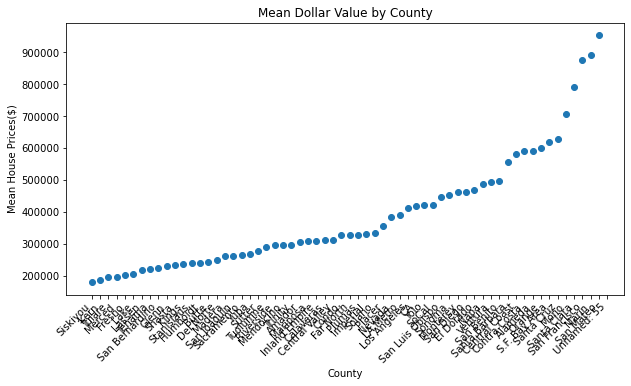

In [5]:
col_means = df.mean(numeric_only=True).sort_values()
plt.figure(figsize=(10, 5))
plt.scatter(col_means.index, col_means.values)
plt.title("Mean Dollar Value by County")
plt.xlabel("County")
plt.ylabel("Mean House Prices($)")
plt.xticks(rotation=45, ha='right')
plt.show()

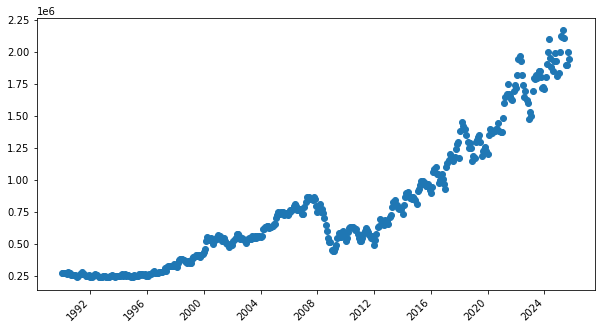

In [6]:
plt.figure(figsize=(10, 5))
plt.scatter(df["Mon-Yr"],df["Santa Clara"])
plt.xticks(rotation=45, ha='right')
plt.show()

In [9]:
ts = df["Mon-Yr"][10]
print(type(df["Mon-Yr"][0]))

print(ts.month)

<class 'pandas._libs.tslibs.timestamps.Timestamp'>
11


In [35]:
df["Mon-Yr"] = pd.to_datetime(df['Mon-Yr'])
df["month"] = df["Mon-Yr"].dt.month
df["year"] = df["Mon-Yr"].dt.year


pivot_df =df.pivot(index='year',columns= 'month',values=county_name)


# SC_gb= df.groupby(['year','month'])['Santa Clara'].mean()
#df.groupby(['col1', 'col2'])['column_to_aggregate'].aggregation_function()


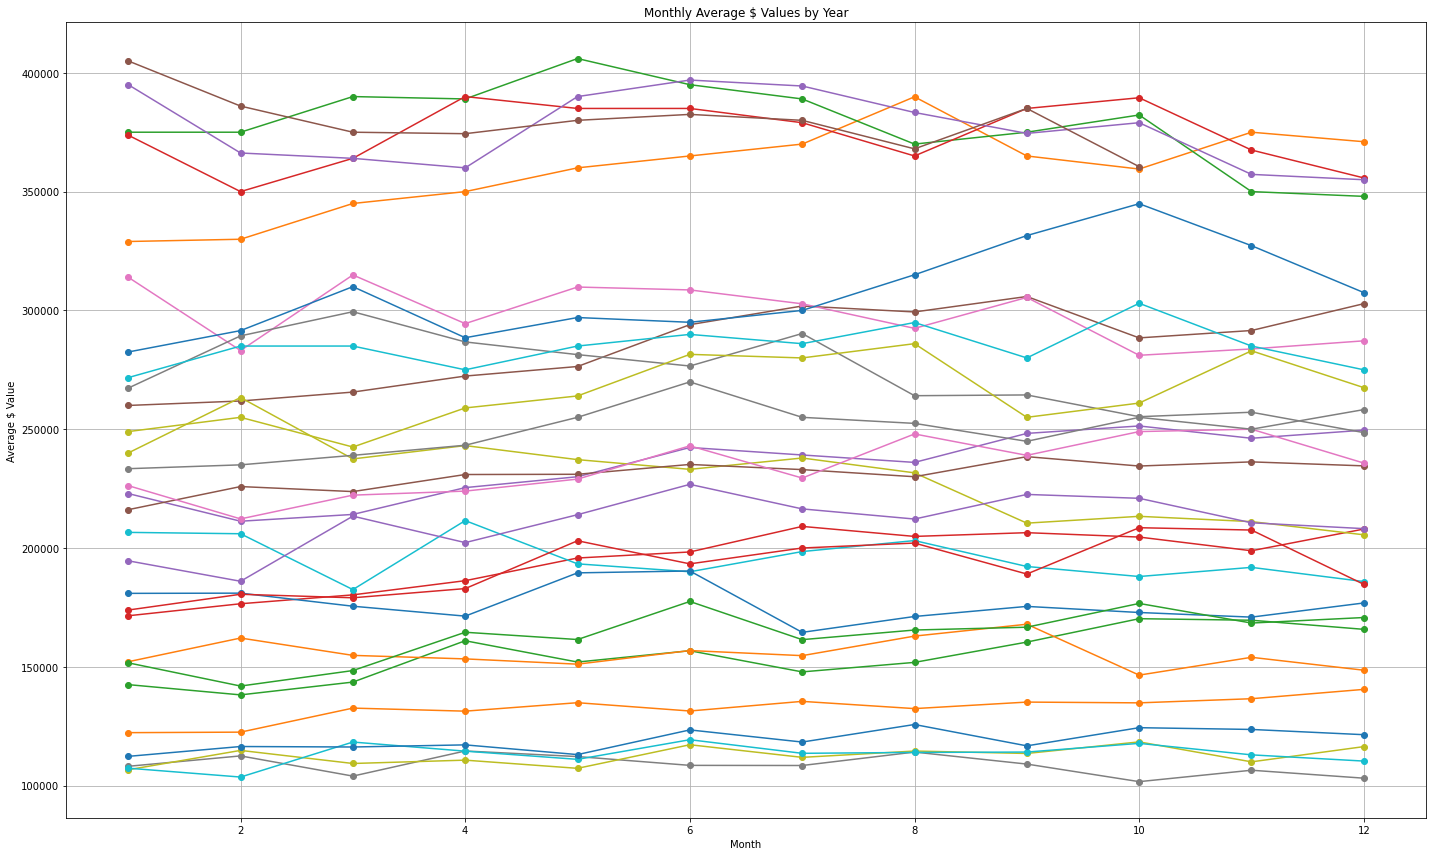

In [36]:
plt.figure(figsize=(20,12))

# iterate through each row (each year), plotting months across the x-axis
for year, row in pivot_df.iterrows():
    plt.plot(row.index, row.values, marker='o', label=str(year))

plt.xlabel("Month")
plt.ylabel("Average $ Value")
plt.title("Monthly Average $ Values by Year")
# plt.legend(title="Year")
plt.grid(True)
plt.tight_layout()
plt.show()

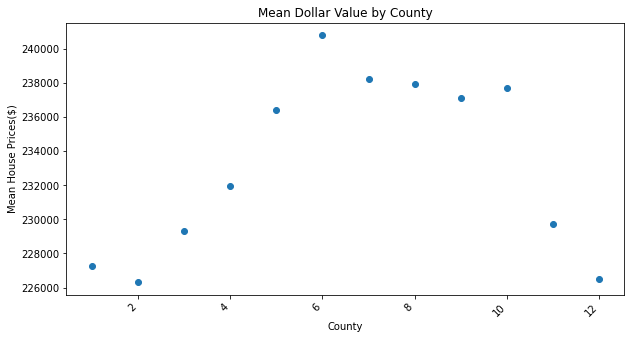

In [37]:
monthly_mean = pivot_df.mean(numeric_only=True)

plt.figure(figsize=(10, 5))
plt.scatter(monthly_mean.index, monthly_mean.values)
plt.title("Mean Dollar Value by County")
plt.xlabel("County")
plt.ylabel("Mean House Prices($)")
plt.xticks(rotation=45, ha='right')
plt.show()

In [15]:
population = pd.read_csv("countydaupoptrends.csv")

pop_sum = population.groupby(["County","Year "])["DauPop"].sum()
print(pop_sum)

County   Year 
Alameda  1998     1401090
         1999     1423529
         2000     1448768
         2001     1465564
         2002     1468468
                   ...   
Yuba     2020       81919
         2021       82256
         2022       82667
         2023       83405
         2024       83959
Name: DauPop, Length: 1566, dtype: int64


In [17]:

pop_sum = pop_sum.reset_index()
pop_pivot = pop_sum.pivot(index="County",columns ="Year ",values="DauPop")
print(pop_pivot)


      index   County  Year    DauPop
0         0  Alameda   1998  1401090
1         1  Alameda   1999  1423529
2         2  Alameda   2000  1448768
3         3  Alameda   2001  1465564
4         4  Alameda   2002  1468468
...     ...      ...    ...      ...
1561   1561     Yuba   2020    81919
1562   1562     Yuba   2021    82256
1563   1563     Yuba   2022    82667
1564   1564     Yuba   2023    83405
1565   1565     Yuba   2024    83959

[1566 rows x 4 columns]
Year                1998     1999     2000     2001     2002     2003  \
County                                                                  
Alameda          1401090  1423529  1448768  1465564  1468468  1467187   
Alpine              1192     1171     1203     1237     1248     1249   
Amador             34098    34769    35205    35784    36535    36776   
Butte             200393   201632   203446   205730   208154   210623   
Calaveras          39677    40288    40658    41428    42119    43186   
Colusa             1

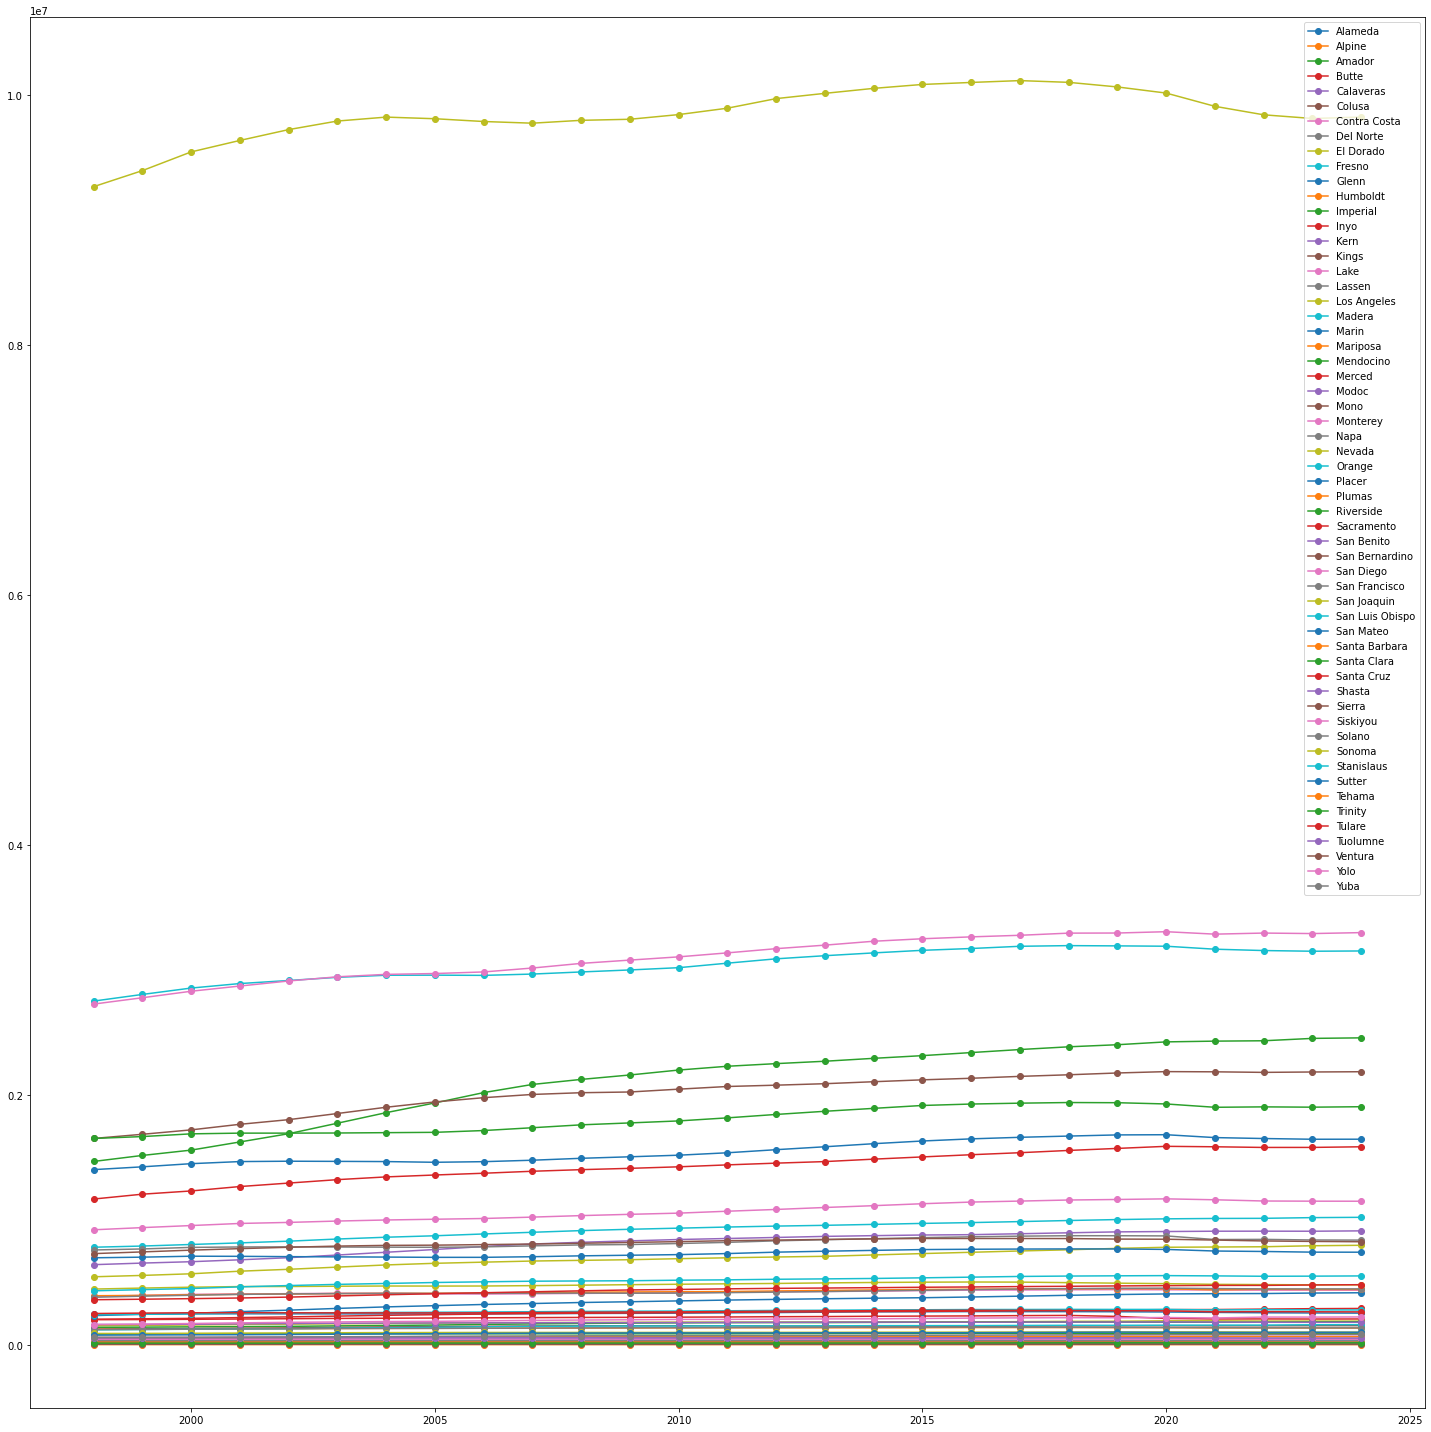

In [25]:
plt.figure(figsize=(20,20))

# iterate through each row (each year), plotting months across the x-axis
# for year, row in pivot_df.iterrows():
for year, county in pop_pivot.iterrows():
    plt.plot(county.index,county.values,marker = 'o', label = str(year))
#     plt.plot(row.index, row.values, marker='o', label=str(year))
# pop_pivot.plot()
# plt.xlabel("Month")
# plt.ylabel("Average $ Value")
# plt.title("Monthly Average $ Values by Year")
plt.legend()
plt.xticks()
# plt.grid(True)
plt.tight_layout()
# plt.show()